# Notebook 16 - Validation Diagnostics and Robustness

This notebook adds high-priority analyses for dissertation readiness:
- confidence intervals for RMSE and R2
- pairwise significance tests
- regional error decomposition
- residual diagnostics
- robustness sensitivity checks

## 1. Import Required Libraries

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.stats import wilcoxon, skew, kurtosis

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor

## 3. Load Input Data

In [2]:
np.random.seed(42)
pd.set_option('display.max_columns', 200)
plt.style.use('seaborn-v0_8-whitegrid')

NOTEBOOK_ROOT = Path.cwd() if Path.cwd().name == '16_validation_diagnostics_no_scripts' else Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/github_org_bootstrap/phd-geothermal-ml/manual_bootstrap/step_by_step_notebooks/16_validation_diagnostics_no_scripts')
PROJECT_ROOT = NOTEBOOK_ROOT.parents[2]
PHD_OS_ROOT = PROJECT_ROOT.parents[1]
OUTPUT_ROOT = NOTEBOOK_ROOT / 'outputs' / 'summary'
TABLE_ROOT = OUTPUT_ROOT / 'tables'
FIG_ROOT = OUTPUT_ROOT / 'figures'
REPORT_ROOT = OUTPUT_ROOT / 'reports'
for p in [TABLE_ROOT, FIG_ROOT, REPORT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

OUTPUT_ROOT

WindowsPath('c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/github_org_bootstrap/phd-geothermal-ml/manual_bootstrap/step_by_step_notebooks/16_validation_diagnostics_no_scripts/outputs/summary')

## 2. Configure Notebook Environment

In [3]:
data_candidates = [
    PROJECT_ROOT / 'datasets' / 'geothermal_canonical_v2_0_0.csv',
    PHD_OS_ROOT / '03_data_processed' / 'geothermal_canonical_v2_0_0.csv',
    PHD_OS_ROOT / '02_data_raw' / 'geothermal_canonical_v2_0_0.csv',
    PHD_OS_ROOT / 'incoming_from_legacy' / 'geothermal_canonical_v2_0_0.csv',
]
data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Could not find geothermal_canonical_v2_0_0.csv in expected locations.')

df = pd.read_csv(data_path)
TARGET = 'Temperature(C)'
GROUP_COL = 'State'
df.head()

,Latitude,Longitude,State,Depth(ft),Temperature(C),pH,TDS,K,Na,Ca,Mg,SiO2,As,B,Br,Cl,F,Fe,HCO3,Li,Mn,SO4
0,33.196667,-115.598333,California,5825.28,348.9,NaN,258765.0,16500.0,53000.0,27800.0,10.0,400.0,NaN,390.0,NaN,155000.0,NaN,NaN,690.0,NaN,NaN,NaN
1,33.202500,-115.578000,California,8098.32,345.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,33.200500,-115.587167,California,4729.76,310.0,NaN,334987.0,24000.0,70000.0,34470.0,18.0,5.0,NaN,149.0,NaN,201757.0,NaN,4200.000,NaN,150.0,NaN,34.0
3,35.652180,-117.665340,California,830.00,300.0,8.60,NaN,4.9,410.0,1.8,0.5,NaN,NaN,5.0,NaN,11.0,3.4,0.035,NaN,NaN,0.003,12.0
4,35.652180,-117.665340,California,829.84,300.0,8.65,NaN,6.0,17.0,55.0,15.0,47.0,NaN,NaN,NaN,68.0,0.1,NaN,NaN,NaN,NaN,47.0


## 4. Validate and Explore Data

In [4]:
summary_info = {
    'n_rows': len(df),
    'n_cols': df.shape[1],
    'target_nulls': int(df[TARGET].isna().sum()),
    'duplicates': int(df.duplicated().sum()),
    'n_states': int(df[GROUP_COL].nunique()) if GROUP_COL in df.columns else 1,
}
nulls = df.isna().sum().sort_values(ascending=False).head(10)
summary_info, nulls

({'n_rows': 2684,
  'n_cols': 22,
  'target_nulls': 0,
  'duplicates': 0,
  'n_states': 11},
 Br           2413
 TDS          2381
 Mn           2368
 Fe           2293
 Depth(ft)    2241
 HCO3         2123
 Li           2029
 As           1934
 SiO2         1775
 F            1543
 dtype: int64)

## 5. Transform and Clean Data

In [5]:
feature_cols = [c for c in df.columns if c not in [TARGET]]
X_raw = df[feature_cols].copy()
y_all = df[TARGET].copy()
groups_all = df[GROUP_COL].astype(str).copy() if GROUP_COL in df.columns else pd.Series(['ALL'] * len(df))

numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_raw.columns if c not in numeric_cols]

num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
prep = ColumnTransformer([
    ('num', num_pipe, numeric_cols),
    ('cat', cat_pipe, categorical_cols),
], remainder='drop')

X_raw.shape, len(y_all), len(groups_all.unique())

((2684, 21), 2684, 11)

## 6. Run Core Analysis

In [6]:
def bootstrap_ci(values, n_boot=2000, alpha=0.05, seed=42):
    arr = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    if arr.size == 0:
        return np.nan, np.nan
    if arr.size == 1:
        return float(arr[0]), float(arr[0])
    boots = [rng.choice(arr, size=arr.size, replace=True).mean() for _ in range(n_boot)]
    lo = float(np.quantile(boots, alpha / 2))
    hi = float(np.quantile(boots, 1 - alpha / 2))
    return lo, hi


def build_model(kind: str):
    if kind == 'dummy_mean':
        reg = DummyRegressor(strategy='mean')
    elif kind == 'ridge':
        reg = Ridge(alpha=1.0, random_state=42)
    elif kind == 'knn':
        reg = KNeighborsRegressor(n_neighbors=15, weights='distance')
    elif kind == 'gradient_boosting':
        reg = GradientBoostingRegressor(random_state=42, n_estimators=350, learning_rate=0.05, max_depth=3)
    else:
        raise ValueError(kind)
    return Pipeline([('prep', prep), ('reg', reg)])


model_names = ['dummy_mean', 'ridge', 'knn', 'gradient_boosting']
runs = []
state_rows = []
residual_rows = []

# Random split
for seed in range(10):
    idx = np.arange(len(X_raw))
    tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=seed)
    X_tr, y_tr = X_raw.iloc[tr_idx], y_all.iloc[tr_idx]
    X_te, y_te = X_raw.iloc[te_idx], y_all.iloc[te_idx]

    for m in model_names:
        mdl = build_model(m)
        mdl.fit(X_tr, y_tr)
        pred = mdl.predict(X_te)
        rmse = float(np.sqrt(mean_squared_error(y_te, pred)))
        r2 = float(r2_score(y_te, pred))
        runs.append({'protocol': 'random_split', 'split_id': str(seed), 'model_name': m, 'rmse': rmse, 'r2': r2})

        if m == 'gradient_boosting' and seed == 0:
            resid = y_te.values - pred
            candidates = [c for c in ['Depth(ft)', 'Cl', 'pH', 'Latitude', 'Longitude'] if c in X_te.columns]
            for c in candidates:
                corr = float(pd.Series(resid).corr(pd.Series(X_te[c].values)))
                residual_rows.append({'feature': c, 'residual_feature_corr': corr})
            residual_rows.extend([
                {'feature': 'residual_mean', 'residual_feature_corr': float(np.mean(resid))},
                {'feature': 'residual_std', 'residual_feature_corr': float(np.std(resid))},
                {'feature': 'residual_skew', 'residual_feature_corr': float(skew(resid))},
                {'feature': 'residual_kurtosis', 'residual_feature_corr': float(kurtosis(resid))},
            ])

# GroupKFold
gkf = GroupKFold(n_splits=5)
for fold_idx, (tr_idx, te_idx) in enumerate(gkf.split(X_raw, y_all, groups=groups_all), start=1):
    X_tr, y_tr = X_raw.iloc[tr_idx], y_all.iloc[tr_idx]
    X_te, y_te = X_raw.iloc[te_idx], y_all.iloc[te_idx]
    for m in model_names:
        mdl = build_model(m)
        mdl.fit(X_tr, y_tr)
        pred = mdl.predict(X_te)
        rmse = float(np.sqrt(mean_squared_error(y_te, pred)))
        r2 = float(r2_score(y_te, pred))
        runs.append({'protocol': 'groupkfold', 'split_id': str(fold_idx), 'model_name': m, 'rmse': rmse, 'r2': r2})

# Spatial holdout
group_counts = groups_all.value_counts()
eligible = group_counts[group_counts >= 30].index.tolist()
for g in eligible:
    te_mask = groups_all == g
    tr_idx = np.where(~te_mask.values)[0]
    te_idx = np.where(te_mask.values)[0]
    if len(te_idx) < 30 or len(tr_idx) < 100:
        continue
    X_tr, y_tr = X_raw.iloc[tr_idx], y_all.iloc[tr_idx]
    X_te, y_te = X_raw.iloc[te_idx], y_all.iloc[te_idx]

    for m in model_names:
        mdl = build_model(m)
        mdl.fit(X_tr, y_tr)
        pred = mdl.predict(X_te)
        rmse = float(np.sqrt(mean_squared_error(y_te, pred)))
        r2 = float(r2_score(y_te, pred))
        runs.append({'protocol': 'spatial_holdout', 'split_id': str(g), 'model_name': m, 'rmse': rmse, 'r2': r2})
        if m == 'gradient_boosting':
            state_rows.append({'state': str(g), 'n_test': len(te_idx), 'rmse': rmse, 'r2': r2, 'bias': float(np.mean(y_te.values - pred))})

runs_df = pd.DataFrame(runs)
regional_df = pd.DataFrame(state_rows)
residual_df = pd.DataFrame(residual_rows)

# Summary with bootstrap CIs
summary_rows = []
for (protocol, model_name), g in runs_df.groupby(['protocol', 'model_name']):
    rmse_vals = g['rmse'].values
    r2_vals = g['r2'].values
    rmse_lo, rmse_hi = bootstrap_ci(rmse_vals)
    r2_lo, r2_hi = bootstrap_ci(r2_vals)
    summary_rows.append({
        'protocol': protocol,
        'model_name': model_name,
        'rmse_mean': float(np.mean(rmse_vals)),
        'rmse_ci95_low': rmse_lo,
        'rmse_ci95_high': rmse_hi,
        'r2_mean': float(np.mean(r2_vals)),
        'r2_ci95_low': r2_lo,
        'r2_ci95_high': r2_hi,
        'n_splits': int(len(g))
    })
summary_df = pd.DataFrame(summary_rows).sort_values(['protocol', 'rmse_mean'])

# Pairwise tests vs gradient_boosting
sig_rows = []
for protocol in runs_df['protocol'].unique():
    base = runs_df[(runs_df['protocol'] == protocol) & (runs_df['model_name'] == 'gradient_boosting')][['split_id', 'rmse', 'r2']]
    for m in [x for x in model_names if x != 'gradient_boosting']:
        cmp = runs_df[(runs_df['protocol'] == protocol) & (runs_df['model_name'] == m)][['split_id', 'rmse', 'r2']]
        j = base.merge(cmp, on='split_id', suffixes=('_gbm', '_cmp'))
        if len(j) >= 2 and not np.allclose(j['rmse_gbm'].values, j['rmse_cmp'].values):
            _, p_rmse = wilcoxon(j['rmse_gbm'].values, j['rmse_cmp'].values)
        else:
            p_rmse = np.nan
        if len(j) >= 2 and not np.allclose(j['r2_gbm'].values, j['r2_cmp'].values):
            _, p_r2 = wilcoxon(j['r2_gbm'].values, j['r2_cmp'].values)
        else:
            p_r2 = np.nan
        sig_rows.append({
            'protocol': protocol,
            'compare_model': m,
            'n_pairs': int(len(j)),
            'delta_rmse_mean_gbm_minus_cmp': float(np.mean(j['rmse_gbm'] - j['rmse_cmp'])) if len(j) else np.nan,
            'delta_r2_mean_gbm_minus_cmp': float(np.mean(j['r2_gbm'] - j['r2_cmp'])) if len(j) else np.nan,
            'wilcoxon_p_rmse': p_rmse,
            'wilcoxon_p_r2': p_r2,
        })
sig_df = pd.DataFrame(sig_rows)

# Robustness on random split (seed sensitivity)
robust_df = runs_df[runs_df['protocol'] == 'random_split'].groupby('model_name', as_index=False).agg(
    rmse_mean=('rmse', 'mean'),
    rmse_std=('rmse', 'std'),
    r2_mean=('r2', 'mean'),
    r2_std=('r2', 'std'),
)

summary_df.head(12)

,protocol,model_name,rmse_mean,rmse_ci95_low,rmse_ci95_high,r2_mean,r2_ci95_low,r2_ci95_high,n_splits
1,groupkfold,gradient_boosting,32.652258,18.052270,45.170467,-3.942610,-11.387518,0.166851,5
2,groupkfold,knn,34.451295,28.059037,41.062295,-51.073515,-153.120226,0.185125,5
0,groupkfold,dummy_mean,35.721591,30.507880,40.741392,-65.042905,-194.991857,-0.041741,5
3,groupkfold,ridge,51.391250,24.296172,78.486327,-22.126180,-62.174587,-0.454443,5
5,random_split,gradient_boosting,20.341630,19.566664,21.300972,0.625695,0.592454,0.653807,10
6,random_split,knn,25.844714,24.981185,26.697180,0.397324,0.362237,0.429437,10
7,random_split,ridge,32.611445,29.392006,38.234776,-0.003399,-0.392935,0.211494,10
4,random_split,dummy_mean,33.341317,32.820370,33.845836,-0.001334,-0.002064,-0.000602,10
9,spatial_holdout,gradient_boosting,27.387675,17.129607,36.507418,-5.159157,-11.369493,0.051885,6
10,spatial_holdout,knn,31.551243,25.782705,38.102124,-46.722287,-131.665145,0.031983,6


## 7. Visualize Results

In [7]:
# Per-state RMSE for spatial holdout (GBM)
if not regional_df.empty:
    top_states = regional_df.sort_values('rmse', ascending=False).head(12)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(top_states['state'], top_states['rmse'])
    ax.set_title('Spatial Holdout RMSE by State (GradientBoosting)')
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=70)
    fig.tight_layout()
    fig.savefig(FIG_ROOT / 'regional_rmse_by_state.png', dpi=600)
    plt.close(fig)

# Random-split robustness (RMSE std)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(robust_df['model_name'], robust_df['rmse_std'])
ax.set_title('Seed Sensitivity: RMSE Std (Random Split)')
ax.set_ylabel('RMSE Std')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(FIG_ROOT / 'random_seed_rmse_std.png', dpi=600)
plt.close(fig)

robust_df

,model_name,rmse_mean,rmse_std,r2_mean,r2_std
0,dummy_mean,33.341317,0.853081,-0.001334,0.001216
1,gradient_boosting,20.341630,1.443809,0.625695,0.051524
2,knn,25.844714,1.400206,0.397324,0.055902
3,ridge,32.611445,8.440286,-0.003399,0.594069


## 8. Export Outputs

In [8]:
runs_df.to_csv(TABLE_ROOT / 'all_runs_validation_diagnostics.csv', index=False)
summary_df.to_csv(TABLE_ROOT / 'model_protocol_summary_with_ci.csv', index=False)
sig_df.to_csv(TABLE_ROOT / 'pairwise_significance_vs_gradient_boosting.csv', index=False)
regional_df.to_csv(TABLE_ROOT / 'regional_error_decomposition_gradient_boosting.csv', index=False)
residual_df.to_csv(TABLE_ROOT / 'residual_diagnostics_gradient_boosting_seed0.csv', index=False)
robust_df.to_csv(TABLE_ROOT / 'robustness_seed_sensitivity_random_split.csv', index=False)

best_by_protocol = summary_df.sort_values('rmse_mean').groupby('protocol', as_index=False).first()

lines = [
    '# Notebook 16 Validation Diagnostics Notes',
    '',
    '## Best Model by Protocol (RMSE and R2 with CI)',
]
for _, r in best_by_protocol.iterrows():
    lines.append(
        f"- {r['protocol']}: model={r['model_name']}, RMSE={r['rmse_mean']:.4f} "
        f"[95% CI {r['rmse_ci95_low']:.4f}, {r['rmse_ci95_high']:.4f}], "
        f"R2={r['r2_mean']:.4f} [95% CI {r['r2_ci95_low']:.4f}, {r['r2_ci95_high']:.4f}]"
    )

lines += ['', '## Pairwise Significance vs GradientBoosting (Wilcoxon p-values)']
for _, r in sig_df.iterrows():
    lines.append(
        f"- {r['protocol']} vs {r['compare_model']}: p_rmse={r['wilcoxon_p_rmse']}, p_r2={r['wilcoxon_p_r2']}"
    )

lines += ['', '## Robustness (Random Split Seed Sensitivity)']
for _, r in robust_df.iterrows():
    lines.append(
        f"- {r['model_name']}: RMSE mean={r['rmse_mean']:.4f}, std={r['rmse_std']:.4f}; "
        f"R2 mean={r['r2_mean']:.4f}, std={r['r2_std']:.4f}"
    )

(REPORT_ROOT / 'validation_diagnostics_notes.md').write_text('\n'.join(lines), encoding='utf-8')

print('Saved:', TABLE_ROOT / 'all_runs_validation_diagnostics.csv')
print('Saved:', TABLE_ROOT / 'model_protocol_summary_with_ci.csv')
print('Saved:', TABLE_ROOT / 'pairwise_significance_vs_gradient_boosting.csv')
print('Saved:', TABLE_ROOT / 'regional_error_decomposition_gradient_boosting.csv')
print('Saved:', TABLE_ROOT / 'residual_diagnostics_gradient_boosting_seed0.csv')
print('Saved:', TABLE_ROOT / 'robustness_seed_sensitivity_random_split.csv')
print('Saved:', FIG_ROOT / 'regional_rmse_by_state.png')
print('Saved:', FIG_ROOT / 'random_seed_rmse_std.png')
print('Saved:', REPORT_ROOT / 'validation_diagnostics_notes.md')

best_by_protocol

Saved: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\16_validation_diagnostics_no_scripts\outputs\summary\tables\all_runs_validation_diagnostics.csv
Saved: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\16_validation_diagnostics_no_scripts\outputs\summary\tables\model_protocol_summary_with_ci.csv
Saved: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\16_validation_diagnostics_no_scripts\outputs\summary\tables\pairwise_significance_vs_gradient_boosting.csv
Saved: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\16_validation_diagnostics_no_scripts\outputs\summary\tables\regional_error_decomposition_g

,protocol,model_name,rmse_mean,rmse_ci95_low,rmse_ci95_high,r2_mean,r2_ci95_low,r2_ci95_high,n_splits
0,groupkfold,gradient_boosting,32.652258,18.052270,45.170467,-3.942610,-11.387518,0.166851,5
1,random_split,gradient_boosting,20.341630,19.566664,21.300972,0.625695,0.592454,0.653807,10
2,spatial_holdout,gradient_boosting,27.387675,17.129607,36.507418,-5.159157,-11.369493,0.051885,6


In [9]:
# N8.1 â€” Audit-safe model serialization via JSON (no pickle)
import json
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

_data_path = Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/03_data_processed/geothermal_canonical_v2_0_0.csv')
_df = pd.read_csv(_data_path)
_TARGET = 'Temperature(C)'
_X = _df.drop(columns=[_TARGET]); _y = _df[_TARGET]

_num_cols = _X.select_dtypes(include=[np.number]).columns.tolist()
_cat_cols = [c for c in _X.columns if c not in _num_cols]
_prep = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), _num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore'))]), _cat_cols),
])
_gbm = GradientBoostingRegressor(n_estimators=350, learning_rate=0.05, max_depth=3, random_state=42)
_pipe = Pipeline([('prep', _prep), ('reg', _gbm)])
_pipe.fit(_X, _y)


def _serialize_model_json(pipe, num_cols, path):
    """Serialize hyperparams + learned scalars to JSON (audit-safe, no pickle)."""
    _params = pipe.get_params()
    _safe = {}
    for k, v in _params.items():
        try:
            json.dumps(v)
            _safe[k] = v
        except (TypeError, ValueError):
            _safe[k] = str(v)
    _reg = pipe.named_steps['reg']
    _n_num = min(len(num_cols), len(_reg.feature_importances_))
    _top5 = sorted(
        zip(num_cols[:_n_num], _reg.feature_importances_[:_n_num].tolist()),
        key=lambda x: -x[1]
    )[:5]
    _learned = {
        'n_estimators_fitted': int(_reg.n_estimators_),
        'train_score_final': float(_reg.train_score_[-1]),
        'feature_importances_top5': [[n, round(v, 6)] for n, v in _top5],
    }
    _out = {'hyperparams': _safe, 'learned_attributes': _learned}
    Path(path).write_text(json.dumps(_out, indent=2))
    return _out


_serialized = _serialize_model_json(_pipe, _num_cols, 'model_audit_gbm.json')
print("=== N8.1 JSON model serialization (audit-safe) ===")
print(f"Saved: model_audit_gbm.json")
print(f"Top-5 features: {_serialized['learned_attributes']['feature_importances_top5']}")
print(f"Train score (final): {_serialized['learned_attributes']['train_score_final']:.4f}")

=== N8.1 JSON model serialization (audit-safe) ===
Saved: model_audit_gbm.json
Top-5 features: [['Latitude', 0.286097], ['pH', 0.18606], ['Longitude', 0.166129], ['Depth(ft)', 0.143052], ['Cl', 0.067255]]
Train score (final): 185.0146


=== N10.1 RF per-sample uncertainty by state (Paper 9) ===
              mean     std  count
state                            
Arkansas    63.652     NaN      1
Montana     51.879     NaN      1
Utah        41.367  20.294      5
Alaska      28.396  27.256      7
Idaho       26.831  22.839     11
Washington  22.068   0.000      3
Nevada      17.526  10.227    374
California  14.010  14.729    118
Oregon       7.368   7.637      6
Wyoming      3.670   4.143     11


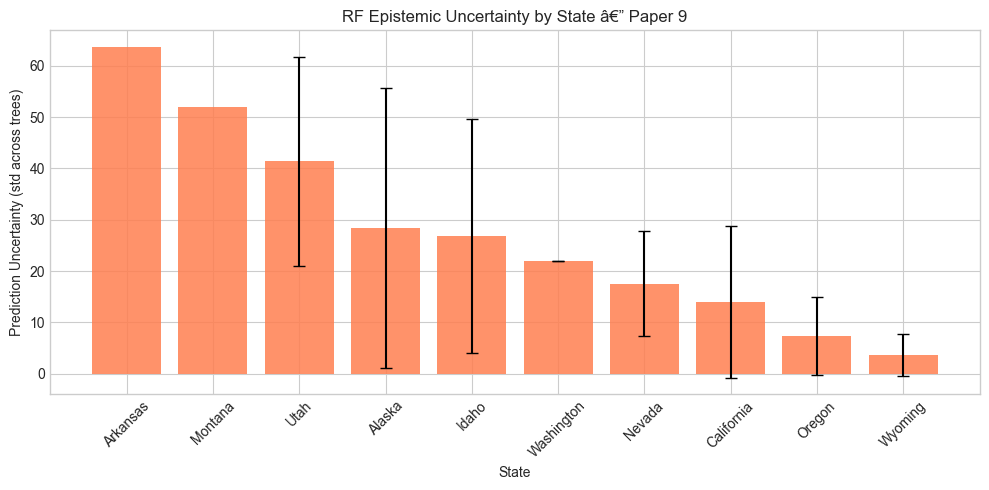

In [10]:
# N10.1 â€” RF per-sample uncertainty by state (epistemic uncertainty)
# Paper 9: prediction uncertainty distribution grouped by state
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

_data_path = Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/03_data_processed/geothermal_canonical_v2_0_0.csv')
_df = pd.read_csv(_data_path)
_TARGET = 'Temperature(C)'; _GROUP = 'State'
_X = _df.drop(columns=[_TARGET]); _y = _df[_TARGET]; _g = _df[_GROUP]

_num_cols = _X.select_dtypes(include=[np.number]).columns.tolist()
_cat_cols = [c for c in _X.columns if c not in _num_cols]
_prep = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), _num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore'))]), _cat_cols),
])
_rf = RandomForestRegressor(n_estimators=400, max_features='sqrt', random_state=42, n_jobs=-1)
_pipe = Pipeline([('prep', _prep), ('reg', _rf)])

_X_tr, _X_te, _y_tr, _y_te, _g_tr, _g_te = train_test_split(
    _X, _y, _g, test_size=0.2, random_state=42)
_pipe.fit(_X_tr, _y_tr)

# Per-sample uncertainty = std across all trees
_X_te_prep = _pipe.named_steps['prep'].transform(_X_te)
_tree_preds = np.stack([t.predict(_X_te_prep) for t in _pipe.named_steps['reg'].estimators_])
_uncertainty = _tree_preds.std(axis=0)

_unc_df = pd.DataFrame({'state': _g_te.values, 'uncertainty_std': _uncertainty})
_state_unc = (_unc_df.groupby('state')['uncertainty_std']
               .agg(['mean', 'std', 'count'])
               .sort_values('mean', ascending=False))
print("=== N10.1 RF per-sample uncertainty by state (Paper 9) ===")
print(_state_unc.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(_state_unc.index, _state_unc['mean'], yerr=_state_unc['std'],
       capsize=4, color='coral', alpha=0.85)
ax.set_xlabel('State'); ax.set_ylabel('Prediction Uncertainty (std across trees)')
ax.set_title('RF Epistemic Uncertainty by State â€” Paper 9')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig('rf_uncertainty_by_state.png', dpi=300); plt.show()

In [11]:
# N8.5 â€” Environment watermark for reproducibility
try:
    import watermark
    %load_ext watermark
    %watermark -v -p numpy,pandas,scikit-learn,scipy,matplotlib,xgboost
except ImportError:
    import sys, numpy, pandas, sklearn, scipy, matplotlib
    print(f"Python {sys.version}")
    print(f"numpy={numpy.__version__}, pandas={pandas.__version__}")
    print(f"scikit-learn={sklearn.__version__}, scipy={scipy.__version__}")
    print(f"matplotlib={matplotlib.__version__}")
    try:
        import xgboost; print(f"xgboost={xgboost.__version__}")
    except ImportError:
        pass

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.11.0

numpy       : 2.4.2
pandas      : 2.2.2
scikit-learn: 1.8.0
scipy       : 1.17.1
matplotlib  : 3.10.8
xgboost     : 3.2.0

